# Local Volatility Model: Interactive Analysis

This notebook provides interactive analysis and visualizations for the Local Volatility model,
including Dupire calibration, surface visualization, and pricing comparisons.

**Topics Covered:**
1. Local Volatility Surface Construction
2. Dupire Calibration from Implied Vol
3. Local Vol vs Implied Vol Comparison
4. Pricing with Local Vol FD
5. Greeks Analysis
6. Smile Dynamics

In [2]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
import sys
sys.path.insert(0, '../..')

# Project imports
from src.marketdata.surfaces.local_vol_surface import LocalVolSurface, FlatLocalVolSurface
from src.marketdata.surfaces.vol_surface import FlatVolSurface, GridVolSurface
from src.calibration.volatility_surface.dupire import DupireCalibrator, DupireConfig, calibrate_local_vol_from_implied
from src.pricers.fx.european_localvol_fde import FxLocalVolFdPricer

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 1. Local Volatility Surface Construction

A local volatility surface $\sigma_{LV}(S, t)$ specifies the instantaneous volatility
as a function of spot price and time.

In [3]:
# Create a local vol surface with typical equity skew pattern
# Higher vol at lower spots (leverage effect)

spot = 100.0
times = np.array([0.1, 0.25, 0.5, 1.0, 2.0])
spots = spot * np.array([0.7, 0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2, 1.3])

# Create local vol grid with skew
base_vol = 0.20
skew_factor = 0.003  # 0.3% per unit away from ATM
term_decay = 0.1     # Smile flattens with time

local_vols = np.zeros((len(times), len(spots)))
for i, t in enumerate(times):
    term_factor = np.exp(-term_decay * t)  # Smile flattens with time
    for j, s in enumerate(spots):
        moneyness = (spot - s) / spot  # Positive for low spots
        local_vols[i, j] = base_vol + skew_factor * moneyness * 100 * term_factor

# Ensure positive
local_vols = np.maximum(local_vols, 0.05)

# Create surface
lv_surface = LocalVolSurface(times=times, spots=spots, local_vols=local_vols)

print(f"Surface shape: {lv_surface.shape}")
print(f"Time range: {lv_surface.time_range}")
print(f"Spot range: {lv_surface.spot_range}")

Surface shape: (5, 9)
Time range: (0.1, 2.0)
Spot range: (70.0, 130.0)


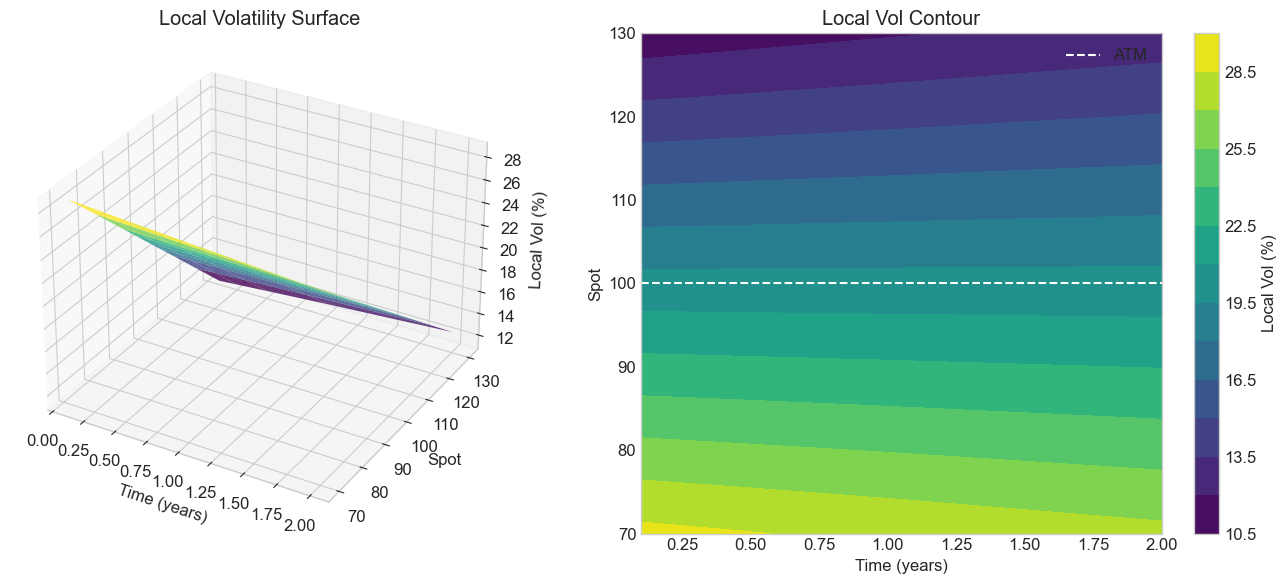

In [4]:
# Visualize the local volatility surface

fig = plt.figure(figsize=(14, 6))

# 3D Surface plot
ax1 = fig.add_subplot(121, projection='3d')
T_mesh, S_mesh = np.meshgrid(times, spots)
ax1.plot_surface(T_mesh, S_mesh, local_vols.T * 100, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Spot')
ax1.set_zlabel('Local Vol (%)')
ax1.set_title('Local Volatility Surface')

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contourf(times, spots, local_vols.T * 100, levels=15, cmap='viridis')
plt.colorbar(contour, ax=ax2, label='Local Vol (%)')
ax2.axhline(y=spot, color='white', linestyle='--', label='ATM')
ax2.set_xlabel('Time (years)')
ax2.set_ylabel('Spot')
ax2.set_title('Local Vol Contour')
ax2.legend()

plt.tight_layout()
plt.show()

## 2. Dupire Calibration from Implied Vol

Dupire's formula extracts local volatility from a surface of implied volatilities:

$$\sigma_{LV}^2(K, T) = \frac{\frac{\partial C}{\partial T} + (r-q)K\frac{\partial C}{\partial K} + qC}{\frac{1}{2}K^2\frac{\partial^2 C}{\partial K^2}}$$

In [5]:
# Create an implied vol surface with smile
expiries = np.array([0.1, 0.25, 0.5, 1.0, 2.0])
strikes = spot * np.array([0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2])

# ATM vol is 20%, smile adds vol at wings
atm_vol = 0.20
smile_curvature = 0.0005  # Convexity
skew_slope = 0.0015       # Skew

implied_vols = np.zeros((len(expiries), len(strikes)))
for i, T in enumerate(expiries):
    for j, K in enumerate(strikes):
        log_moneyness = np.log(K / spot)
        # Smile decays with sqrt(T)
        implied_vols[i, j] = atm_vol - skew_slope * log_moneyness * 100 / np.sqrt(T) + \
                             smile_curvature * (log_moneyness * 100)**2 / np.sqrt(T)

# Ensure positive
implied_vols = np.maximum(implied_vols, 0.05)

implied_surface = GridVolSurface(expiries=expiries, strikes=strikes, implied_vols=implied_vols)

print("Implied Vol Surface (%):\n")
print("         ", end="")
for K in strikes:
    print(f"{K:>8.1f}", end="")
print()
for i, T in enumerate(expiries):
    print(f"T={T:.2f}  ", end="")
    for j in range(len(strikes)):
        print(f"{implied_vols[i,j]*100:>8.2f}", end="")
    print()

Implied Vol Surface (%):

             80.0    90.0    95.0   100.0   105.0   110.0   120.0
T=0.10    109.31   42.55   26.59   20.00   21.45   29.84   63.91
T=0.25     76.49   34.26   24.17   20.00   20.92   26.22   47.77
T=0.50     59.94   30.08   22.95   20.00   20.65   24.40   39.64
T=1.00     48.24   27.13   22.08   20.00   20.46   23.11   33.89
T=2.00     39.97   25.04   21.47   20.00   20.32   22.20   29.82


In [6]:
# Calibrate local vol from implied vol using Dupire's formula

r = 0.05  # Domestic rate
q = 0.02  # Foreign rate

calibrator = DupireCalibrator(config=DupireConfig(dT=0.01, dK_pct=0.01))

# Calibrate on a grid
calib_times = np.array([0.1, 0.25, 0.5, 1.0, 2.0])
calib_spots = spot * np.array([0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15])

calibrated_lv = calibrator.calibrate_grid(
    implied_surface=implied_surface,
    spot=spot,
    r=r,
    q=q,
    times=calib_times,
    spots=calib_spots,
)

print("\nCalibrated Local Vol Surface (%):\n")
print("         ", end="")
for s in calib_spots:
    print(f"{s:>8.1f}", end="")
print()
for i, T in enumerate(calib_times):
    print(f"T={T:.2f}  ", end="")
    for j in range(len(calib_spots)):
        print(f"{calibrated_lv.local_vols[i,j]*100:>8.2f}", end="")
    print()


Calibrated Local Vol Surface (%):

             85.0    90.0    95.0   100.0   105.0   110.0   115.0
T=0.10     75.93    9.39   10.65    9.62   10.92   11.56   91.29
T=0.25     55.37    6.57    8.09    8.01    8.88    8.93   69.94
T=0.50     45.01    5.10    6.62    6.88    7.64    7.55   51.55
T=1.00     37.69    3.84    5.37    5.85    6.58    6.47   38.42
T=2.00     32.51    3.08    4.40    4.94    5.71    5.75   31.78


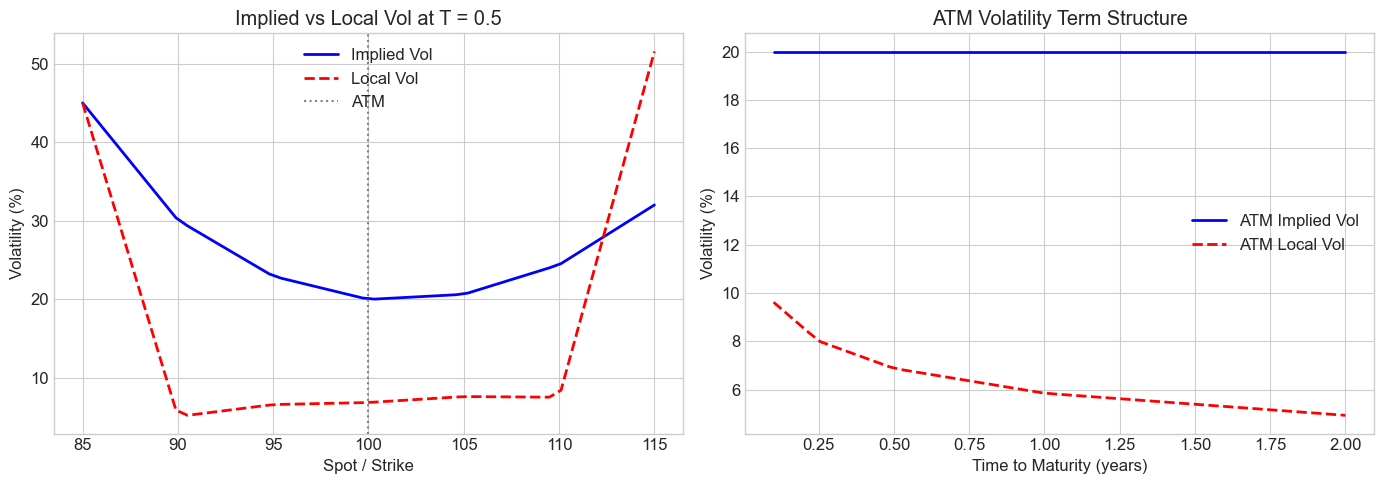

In [7]:
# Compare implied vol and local vol at different spots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot vol vs spot at T=0.5
T_query = 0.5
spot_range = np.linspace(85, 115, 50)

implied_vols_slice = [implied_surface.implied_vol(T_query, K) * 100 for K in spot_range]
local_vols_slice = [calibrated_lv.local_vol(s, T_query) * 100 for s in spot_range]

axes[0].plot(spot_range, implied_vols_slice, 'b-', linewidth=2, label='Implied Vol')
axes[0].plot(spot_range, local_vols_slice, 'r--', linewidth=2, label='Local Vol')
axes[0].axvline(x=spot, color='gray', linestyle=':', label='ATM')
axes[0].set_xlabel('Spot / Strike')
axes[0].set_ylabel('Volatility (%)')
axes[0].set_title(f'Implied vs Local Vol at T = {T_query}')
axes[0].legend()
axes[0].grid(True)

# Plot vol vs time at ATM
time_range = np.linspace(0.1, 2.0, 50)
K_atm = spot

implied_vols_term = [implied_surface.implied_vol(T, K_atm) * 100 for T in time_range]
local_vols_term = [calibrated_lv.local_vol(K_atm, T) * 100 for T in time_range]

axes[1].plot(time_range, implied_vols_term, 'b-', linewidth=2, label='ATM Implied Vol')
axes[1].plot(time_range, local_vols_term, 'r--', linewidth=2, label='ATM Local Vol')
axes[1].set_xlabel('Time to Maturity (years)')
axes[1].set_ylabel('Volatility (%)')
axes[1].set_title('ATM Volatility Term Structure')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3. Pricing with Local Vol FD

Price European options using finite difference methods with the local volatility surface.

In [8]:
# Black-Scholes price for comparison
def bs_price(S, K, T, r, q, sigma, option_type='call'):
    """Black-Scholes price."""
    if T <= 0:
        if option_type == 'call':
            return max(S - K, 0)
        else:
            return max(K - S, 0)
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

In [9]:
# Compare pricing: Local Vol FD vs Black-Scholes with ATM vol

# Use flat local vol (should match BS)
flat_lv = FlatLocalVolSurface(sigma=0.20)
pricer_flat = FxLocalVolFdPricer(local_vol_surface=flat_lv, n_space=201, n_time_steps=100)

# Test parameters
S0 = 100.0
K = 100.0
T = 1.0
r_d = 0.05
r_f = 0.02
sigma = 0.20

# Prices
lv_call = pricer_flat.price_european(spot=S0, strike=K, maturity=T, 
                                      domestic_rate=r_d, foreign_rate=r_f, option_type='call')
bs_call = bs_price(S0, K, T, r_d, r_f, sigma, 'call')

lv_put = pricer_flat.price_european(spot=S0, strike=K, maturity=T,
                                     domestic_rate=r_d, foreign_rate=r_f, option_type='put')
bs_put = bs_price(S0, K, T, r_d, r_f, sigma, 'put')

print("Pricing Comparison (Flat Local Vol vs Black-Scholes):")
print(f"{'':>15} {'Local Vol FD':>15} {'Black-Scholes':>15} {'Diff (bp)':>15}")
print(f"{'ATM Call':>15} {lv_call:>15.4f} {bs_call:>15.4f} {(lv_call-bs_call)*10000:>15.2f}")
print(f"{'ATM Put':>15} {lv_put:>15.4f} {bs_put:>15.4f} {(lv_put-bs_put)*10000:>15.2f}")

Pricing Comparison (Flat Local Vol vs Black-Scholes):
                   Local Vol FD   Black-Scholes       Diff (bp)
       ATM Call          9.2281          9.2270           11.00
        ATM Put          6.3302          6.3301            0.69


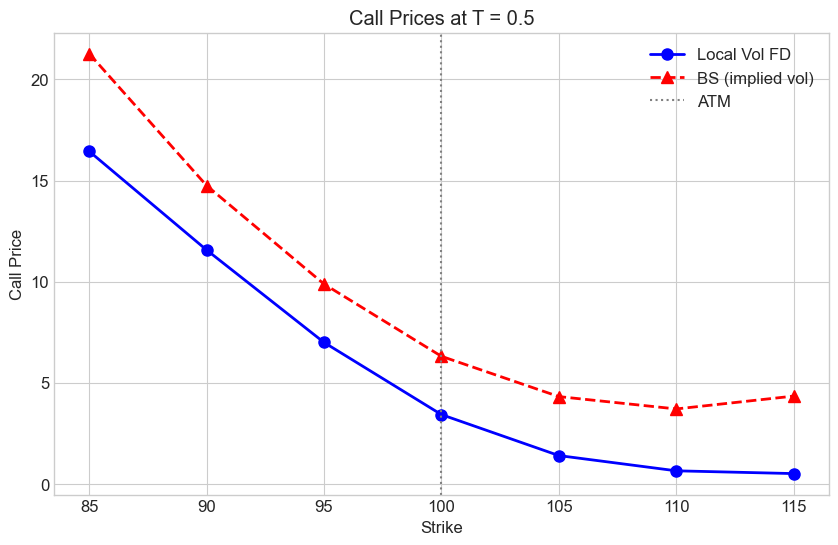

In [10]:
# Price across strikes with calibrated local vol

pricer_lv = FxLocalVolFdPricer(local_vol_surface=calibrated_lv, n_space=201, n_time_steps=100)

strikes_test = spot * np.array([0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15])
T_test = 0.5

lv_prices = []
bs_prices = []
for K in strikes_test:
    lv_p = pricer_lv.price_european(spot=spot, strike=K, maturity=T_test,
                                    domestic_rate=r_d, foreign_rate=r_f, option_type='call')
    sigma_bs = implied_surface.implied_vol(T_test, K)
    bs_p = bs_price(spot, K, T_test, r_d, r_f, sigma_bs, 'call')
    lv_prices.append(lv_p)
    bs_prices.append(bs_p)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(strikes_test, lv_prices, 'bo-', markersize=8, linewidth=2, label='Local Vol FD')
ax.plot(strikes_test, bs_prices, 'r^--', markersize=8, linewidth=2, label='BS (implied vol)')
ax.axvline(x=spot, color='gray', linestyle=':', label='ATM')
ax.set_xlabel('Strike')
ax.set_ylabel('Call Price')
ax.set_title(f'Call Prices at T = {T_test}')
ax.legend()
ax.grid(True)
plt.show()

## 4. Smile Dynamics

One key limitation of local vol is its prediction of smile dynamics.
Local vol predicts that the smile flattens as we move forward in time.

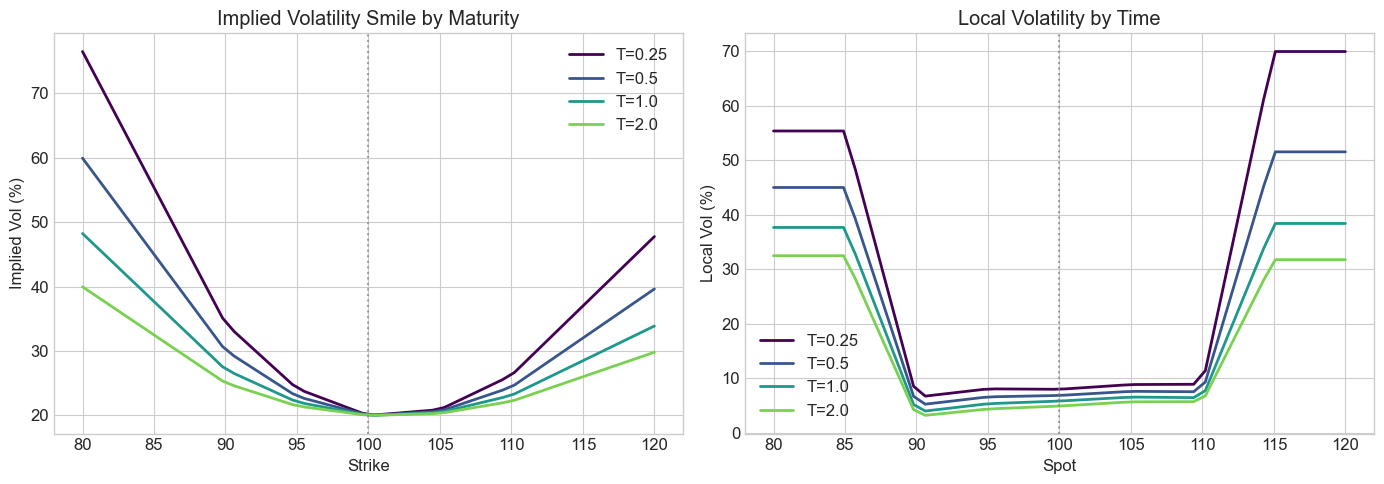


Key Observation:
The implied vol smile flattens with maturity, which is realistic.
Local vol captures this - but may give incorrect forward smile dynamics.


In [11]:
# Visualize how local vol predicts smile evolution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

maturities = [0.25, 0.5, 1.0, 2.0]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(maturities)))

strike_range = np.linspace(80, 120, 50)

# Implied vol smile at different maturities
for T, color in zip(maturities, colors):
    implied_smile = [implied_surface.implied_vol(T, K) * 100 for K in strike_range]
    axes[0].plot(strike_range, implied_smile, color=color, linewidth=2, label=f'T={T}')

axes[0].axvline(x=spot, color='gray', linestyle=':', alpha=0.7)
axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Implied Vol (%)')
axes[0].set_title('Implied Volatility Smile by Maturity')
axes[0].legend()
axes[0].grid(True)

# Local vol at different maturities
for T, color in zip(maturities, colors):
    local_smile = [calibrated_lv.local_vol(K, T) * 100 for K in strike_range]
    axes[1].plot(strike_range, local_smile, color=color, linewidth=2, label=f'T={T}')

axes[1].axvline(x=spot, color='gray', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Spot')
axes[1].set_ylabel('Local Vol (%)')
axes[1].set_title('Local Volatility by Time')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nKey Observation:")
print("The implied vol smile flattens with maturity, which is realistic.")
print("Local vol captures this - but may give incorrect forward smile dynamics.")

## 5. Key Takeaways

### Local Volatility Model Summary:

1. **Exact Vanilla Fit**: Local vol prices all vanillas correctly by construction
2. **Dupire Calibration**: Extract σ(S,t) from implied vol surface
3. **Arbitrage-Free**: No-arbitrage guaranteed for vanillas
4. **Smile Dynamics**: Predicts flattening smile (may be unrealistic)

### When to Use:
- European exotic pricing benchmark
- Vol surface interpolation
- Initial calibration for more complex models

### Limitations:
- Forward smile dynamics may be incorrect
- Can misprice barrier and path-dependent options
- Sensitive to input surface quality